In [34]:
import pandas as pd
import numpy as np 
import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
import tensorflow as tf

In [3]:
TrainData = pd.read_csv("./Dados/DataSpline2.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)
TrainData = TrainData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [10]:
def create_delta_data(local_data):
    OriginalData = pd.read_csv(local_data)
    OriginalData.index = (np.arange(0, len(OriginalData), 1).astype(float) * 0.07).round(5)
    OriginalData = OriginalData.drop(columns=["x(Wd,We)", "y(Wd,We)"])
    theta = OriginalData["theta(Wd,We)"].to_numpy()
    theta_0 = theta[1:]
    theta_1 = theta[:-1]
    delta_theta = theta_0 - theta_1
    wd_alinhado = OriginalData['Wd'].iloc[:-1]  
    we_alinhado = OriginalData['We'].iloc[:-1] 
    df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta
    })
    print(df_new.head())
    print("Shape do novo_df:", df_new.shape)
    return df_new

TrainData = create_delta_data("./Dados/DataSpline.csv")
TestData = create_delta_data("./Dados/DataSpline2.csv")
ValData = create_delta_data("./Dados/DataSpline3.csv")

            Wd        We  delta_theta
0.00  2.226270  2.241090     0.000227
0.07  2.226960  2.241623     0.000223
0.14  2.227650  2.242156     0.000220
0.21  2.228340  2.242689     0.000216
0.28  2.229031  2.243222     0.000213
Shape do novo_df: (2145, 3)
            Wd        We  delta_theta
0.00  2.182290  2.212843    -0.002094
0.07  2.183373  2.213715    -0.002065
0.14  2.184457  2.214588    -0.002035
0.21  2.185540  2.215461    -0.002006
0.28  2.186624  2.216334    -0.001977
Shape do novo_df: (2026, 3)
            Wd        We  delta_theta
0.00  2.018930  2.075716     0.002759
0.07  2.021475  2.077897     0.002669
0.14  2.024019  2.080078     0.002580
0.21  2.026563  2.082259     0.002492
0.28  2.029108  2.084440     0.002405
Shape do novo_df: (1325, 3)


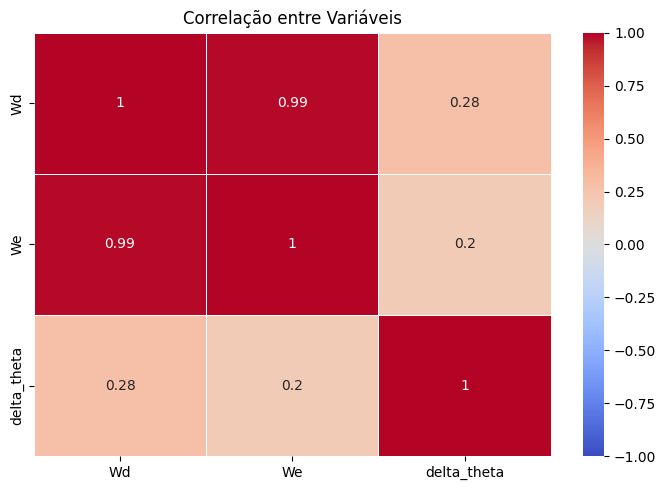

In [11]:
# Selecione apenas colunas numéricas
numeric_cols = TrainData.select_dtypes(include=[np.number]).columns
corr_matrix = TrainData[numeric_cols].corr()

# Criar mapa de calor
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlação entre Variáveis')
plt.tight_layout()
plt.show()

In [76]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()
print(train_x.shape)

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()

(2145, 2)


In [14]:
def compile_model(model, epochs=5000):
    # Compila e treina o modelo
    model.compile(loss="mse", optimizer="adam")
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=True)

    # Previsões
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics

In [75]:
import os
import random

os.environ['PYTHONHASHSEED'] = '47'
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # força operações determinísticas no TF (em CPU/GPU)
random.seed(47)
np.random.seed(47)
tf.random.set_seed(47)

c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 12: early stopping
Restoring model weights from the end of the best epoch: 7.
dict_keys(['attempts', 'damping_factor', 'loss', 'val_loss'])
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

Training Metrics:
  R2: 0.6410
  MSE: 0.0000
  RMSE: 0.0012
  MAPE: 2.3673

Validation Metrics:
  R2: -0.1746
  MSE: 0.0000
  RMSE: 0.0039
  MAPE: 1.7644

Test Metrics:
  R2: -3.3907
  MSE: 0.0000
  RMSE: 0.0035
  MAPE: 4.5551


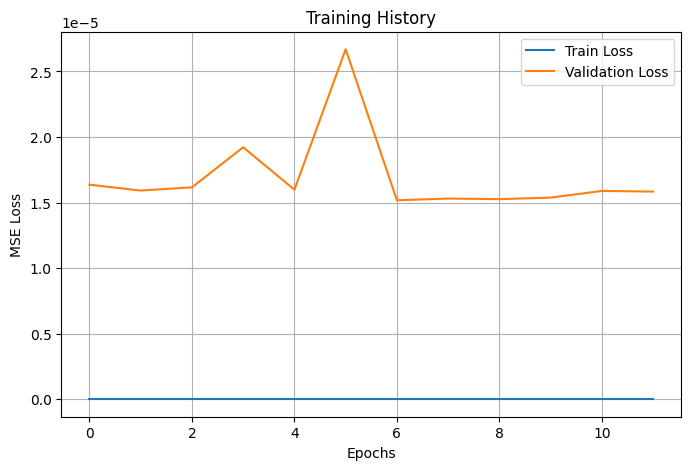

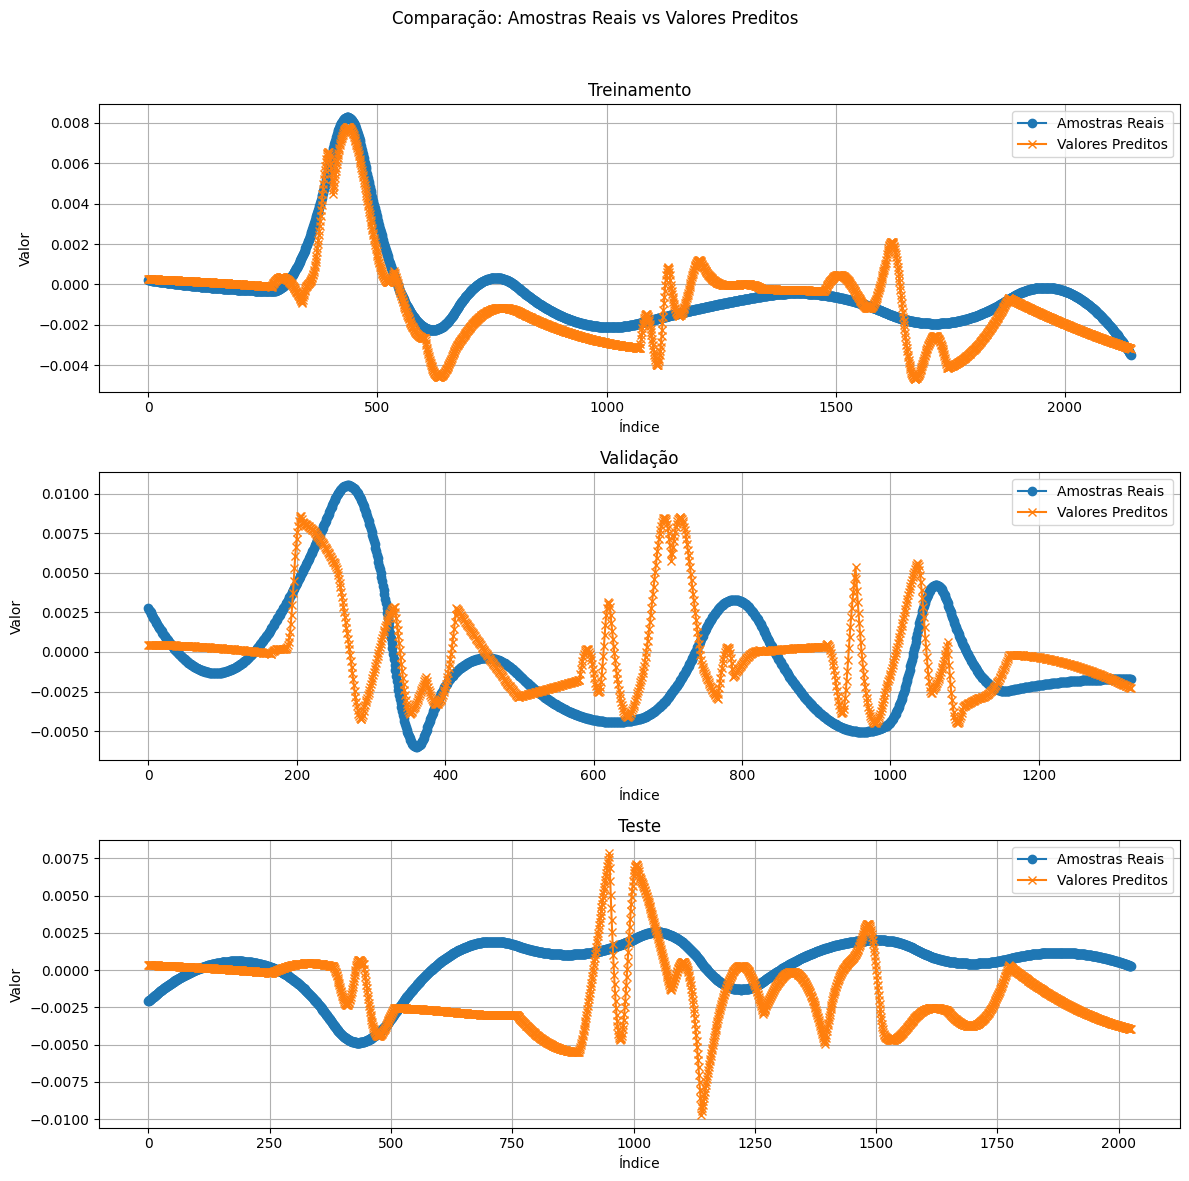

In [113]:
import tf_levenberg_marquardt as lm
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0,
    restore_best_weights=True,
    verbose=1
)

model = keras.Sequential([
    keras.layers.Dense(20, activation='tanh', input_shape=(len(PREDICTORS),)),
    keras.layers.Dense(10, activation='tanh'),
    keras.layers.Dense(1)
])

model_wrapper = lm.model.ModelWrapper(keras.models.clone_model(model))

model_wrapper.compile(
    optimizer=keras.optimizers.SGD(learning_rate=1.0), loss=lm.loss.MeanSquaredError()
)

history = model_wrapper.fit(train_x, train_y, epochs=500, validation_data=(x_val, y_val), verbose=False, callbacks=[early_stopping_callback])


print(model_wrapper.history.history.keys())
# Previsões
train_pred = model_wrapper.predict(train_x) 
val_pred = model_wrapper.predict(x_val)
test_pred = model_wrapper.predict(x_test)
# Cálculo das métricas  
metrics = {
    'Training': {
        'R2': r2_score(train_y, train_pred),
        'MSE': mean_squared_error(train_y, train_pred),
        'RMSE': root_mean_squared_error(train_y, train_pred),
        'MAPE': mean_absolute_percentage_error(train_y, train_pred)
    },
    'Validation': {
        'R2': r2_score(y_val, val_pred),
        'MSE': mean_squared_error(y_val, val_pred),
        'RMSE': root_mean_squared_error(y_val, val_pred),
        'MAPE': mean_absolute_percentage_error(y_val, val_pred)
    },
    'Test': {
        'R2': r2_score(y_test, test_pred),
        'MSE': mean_squared_error(y_test, test_pred),
        'RMSE': root_mean_squared_error(y_test, test_pred),
        'MAPE': mean_absolute_percentage_error(y_test, test_pred)
    }
}
# Imprime as métricas
for name, m in metrics.items():
    print(f"\n{name} Metrics:")
    for k, v in m.items():
        print(f"  {k}: {v:.4f}")
# Gráfico do histórico de treinamento
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.show()
# Gráficos comparativos
fig, axs = plt.subplots(3, 1, figsize=(12, 12))
datasets = [
    ('Treinamento', train_y, train_pred),
    ('Validação', y_val, val_pred),
    ('Teste', y_test, test_pred)
]
for i, (title, y_true, y_pred) in enumerate(datasets):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    axs[i].plot(y_true, marker='o', label='Amostras Reais')
    axs[i].plot(y_pred, marker='x', label='Valores Preditos')
    axs[i].set_title(f'{title}')
    axs[i].set_xlabel('Índice')
    axs[i].set_ylabel('Valor')
    axs[i].legend()
    axs[i].grid(True)
plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()




In [106]:
def root_mean_squared_error(y_true, y_pred):
    y_true_np = y_true.numpy() if hasattr(y_true, 'numpy') else y_true
    y_pred_np = y_pred.numpy() if hasattr(y_pred, 'numpy') else y_pred
    return np.sqrt(mean_squared_error(y_true_np, y_pred_np))

def custom_train_model_with_es_physics(model,
                                       train_x, train_y,
                                       x_val, y_val,
                                       x_test, y_test,
                                       restrictions_data,
                                       Ts, L, R,
                                       lambda1=1.0, lambda2=1.0,
                                       epochs=5000, patience=50,
                                       min_delta=0, plot=True,
                                       learning_rate=0.001, use_early_stopping=True):
    """
    Treina um modelo Keras com Adam + Early Stopping e adiciona um termo
    físico MSE_f na loss:

        MSE_f = mean( ((y[k] - y[k-1]) / Ts - (R/L)*(Wd[k-1] - We[k-1]))^2 )

    Loss = lambda1 * MSE_d + lambda2 * MSE_f
    """

    # converter para tf.Tensor float32
    def to_tensor(x):
        return tf.constant(x, dtype=tf.float32) if not tf.is_tensor(x) else tf.cast(x, tf.float32)
    train_x = to_tensor(train_x); train_y = to_tensor(train_y)
    x_val   = to_tensor(x_val);   y_val   = to_tensor(y_val)
    x_test  = to_tensor(x_test);  y_test  = to_tensor(y_test)
    restrictions_data = to_tensor(restrictions_data)

    optimizer = Adam(learning_rate=learning_rate)
    mse_loss  = MeanSquaredError()

    train_hist, val_hist = [], []
    best_val, wait, best_w = float('inf'), 0, None

    print(f"Treinando com Ts={Ts}, L={L}, R={R}, λ1={lambda1}, λ2={lambda2}")
    for epoch in range(1, epochs+1):
        with tf.GradientTape() as tape:
            # 1) predições
            y_pred = model(train_x, training=True)  # shape [N,1]

            # 2) termo convencional MSE_d
            MSE_d = mse_loss(train_y, y_pred)

            # 3) termo físico MSE_f
            # descartamos o primeiro ponto: predições[1:], predições[:-1]
            #y_k   = y_pred[1:]
            #y_km1 = y_pred[:-1]
            # entradas correspondentes Wd, We no instante k-1
            x1_km1 = restrictions_data[:, 0]   # Wd
            x2_km1 = restrictions_data[:, 1]   # We

            # calcula derivada aproximada
            #dy_dt = (y_k - y_km1) / Ts
            phys  = (R / L) * (x1_km1 - x2_km1) * Ts
            MSE_f = tf.reduce_mean(tf.square(y_pred - phys))

            # 4) loss total
            loss = lambda1 * MSE_d + lambda2 * MSE_f

        # grads e atualização
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # validação
        yv = model(x_val, training=False)
        val_d = mse_loss(y_val, yv)
        # para simplicidade não calculo val_f

        train_hist.append(loss.numpy())
        val_hist.append(val_d.numpy())

        if use_early_stopping:
        # early stopping
            if val_d.numpy() < best_val - min_delta:
                best_val = val_d.numpy(); wait = 0
                best_w = model.get_weights()
            else:
                wait += 1

            if wait >= patience:
                print(f"Early stopping na época {epoch}")
                model.set_weights(best_w)
                break

        if epoch % 50 == 0 or epoch == 1:
            print(f"Epoch {epoch}: Loss={loss.numpy():.4g}, MSE_d={MSE_d.numpy():.4g}, MSE_f={MSE_f.numpy():.4g}, Val MSE={val_d.numpy():.4g}")

    # avaliando métricas finais
    def eval_metrics(x, y):
        yp = model(x, training=False)
        y_np, yp_np = y.numpy(), yp.numpy()
        return {
            'R2': r2_score(y_np, yp_np),
            'MSE': mean_squared_error(y_np, yp_np),
            'RMSE': root_mean_squared_error(y_np, yp_np),
            'MAPE': mean_absolute_percentage_error(y_np, yp_np)
        }

    metrics = {
        'Training':   eval_metrics(train_x, train_y),
        'Validation': eval_metrics(x_val,   y_val),
        'Test':       eval_metrics(x_test,  y_test),
    }

    for split, m in metrics.items():
        print(f"\n{split} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4g}")
            
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # CORREÇÃO: Conversão robusta para arrays numpy para cálculo de métricas sklearn
    # Usamos hasattr(var, 'numpy') para verificar se é um Tensor antes de chamar .numpy()
    train_y_np = train_y.numpy() if hasattr(train_y, 'numpy') else train_y
    train_pred_np = train_pred.numpy() if hasattr(train_pred, 'numpy') else train_pred
    y_val_np = y_val.numpy() if hasattr(y_val, 'numpy') else y_val
    val_pred_np = val_pred.numpy() if hasattr(val_pred, 'numpy') else val_pred
    y_test_np = y_test.numpy() if hasattr(y_test, 'numpy') else y_test
    test_pred_np = test_pred.numpy() if hasattr(test_pred, 'numpy') else test_pred
    # opcional: plot de loss
    if plot:
        plt.plot(train_hist, label='Train Loss')
        plt.plot(val_hist,   label='Val MSE_d')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.legend(); plt.grid(True)
        plt.show()

        # Gráficos comparativos
        fig, axs = plt.subplots(3, 1, figsize=(12, 12))
        datasets = [
            ('Treinamento', train_y_np, train_pred_np), 
            ('Validação', y_val_np, val_pred_np),
            ('Teste', y_test_np, test_pred_np)
        ]

        for i, (title, y_true, y_pred) in enumerate(datasets):
            y_true_flat = np.ravel(y_true)
            y_pred_flat = np.ravel(y_pred)
            axs[i].plot(y_true_flat, marker='o', label='Amostras Reais')
            axs[i].plot(y_pred_flat, marker='x', label='Valores Preditos')
            axs[i].set_title(f'{title}')
            axs[i].set_xlabel('Índice')
            axs[i].set_ylabel('Valor')
            axs[i].legend()
            axs[i].grid(True)

        plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

        #print(model.trainable_variables)

    return metrics

In [107]:
TrainDataPINN = pd.read_csv("./Dados/DataSplineCompleto.csv")
TrainDataPINN.index = (np.arange(0, len(TrainDataPINN), 1).astype(float) * 0.07).round(5)
TrainDataPINN = TrainDataPINN.drop(columns=["x(Wd,We)", "y(Wd,We)"])


theta = TrainDataPINN["theta(Wd,We)"].to_numpy()
theta_0 = theta[1:]
theta_1 = theta[:-1]
delta_theta = theta_0 - theta_1
wd_alinhado = TrainDataPINN['Wd'].iloc[:-1]  
we_alinhado = TrainDataPINN['We'].iloc[:-1] 
wd_true_al = TrainDataPINN['Wd_true'].iloc[:-1]
we_true_al = TrainDataPINN['We_true'].iloc[:-1]
df_new = pd.DataFrame({
        'Wd': wd_alinhado,
        'We': we_alinhado,
        'delta_theta': delta_theta,
        'Wd_true' : wd_true_al,
        'We_true' : we_true_al})
print(df_new.head())

RESTRICTIONS = ["Wd_true", "We_true"]
PREDICTORS = ["Wd", "We"]
TARGET = "delta_theta"


Restrictions_data = df_new[RESTRICTIONS].to_numpy()

train_x_pinn = df_new[PREDICTORS].to_numpy()
train_y_pinn = df_new[[TARGET]].to_numpy()

            Wd        We  delta_theta   Wd_true   We_true
0.00  2.226270  2.241090     0.000227  0.098776 -0.753213
0.07  2.226960  2.241623     0.000223  0.171523 -0.590182
0.14  2.227650  2.242156     0.000220  0.244269 -0.427151
0.21  2.228340  2.242689     0.000216  0.317015 -0.264119
0.28  2.229031  2.243222     0.000213  0.389762 -0.101088


Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0, λ2=1.0
Epoch 1: Loss=0.5001, MSE_d=0.4995, MSE_f=0.5001, Val MSE=0.3603
Early stopping na época 18

Training Metrics:
  R2: -1217
  MSE: 0.004823
  RMSE: 0.06944
  MAPE: 191.2

Validation Metrics:
  R2: -690.6
  MSE: 0.008933
  RMSE: 0.09451
  MAPE: 91.4

Test Metrics:
  R2: -1391
  MSE: 0.003785
  RMSE: 0.06153
  MAPE: 98.79
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


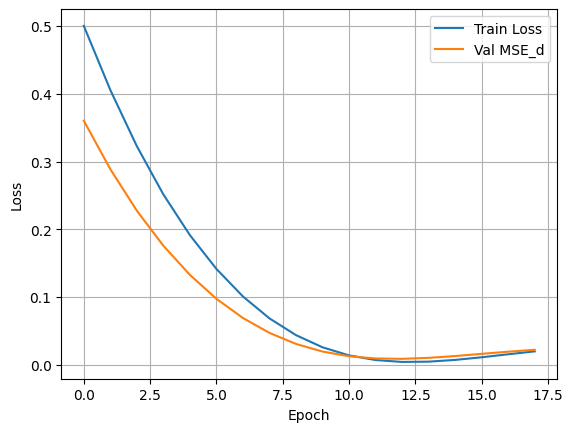

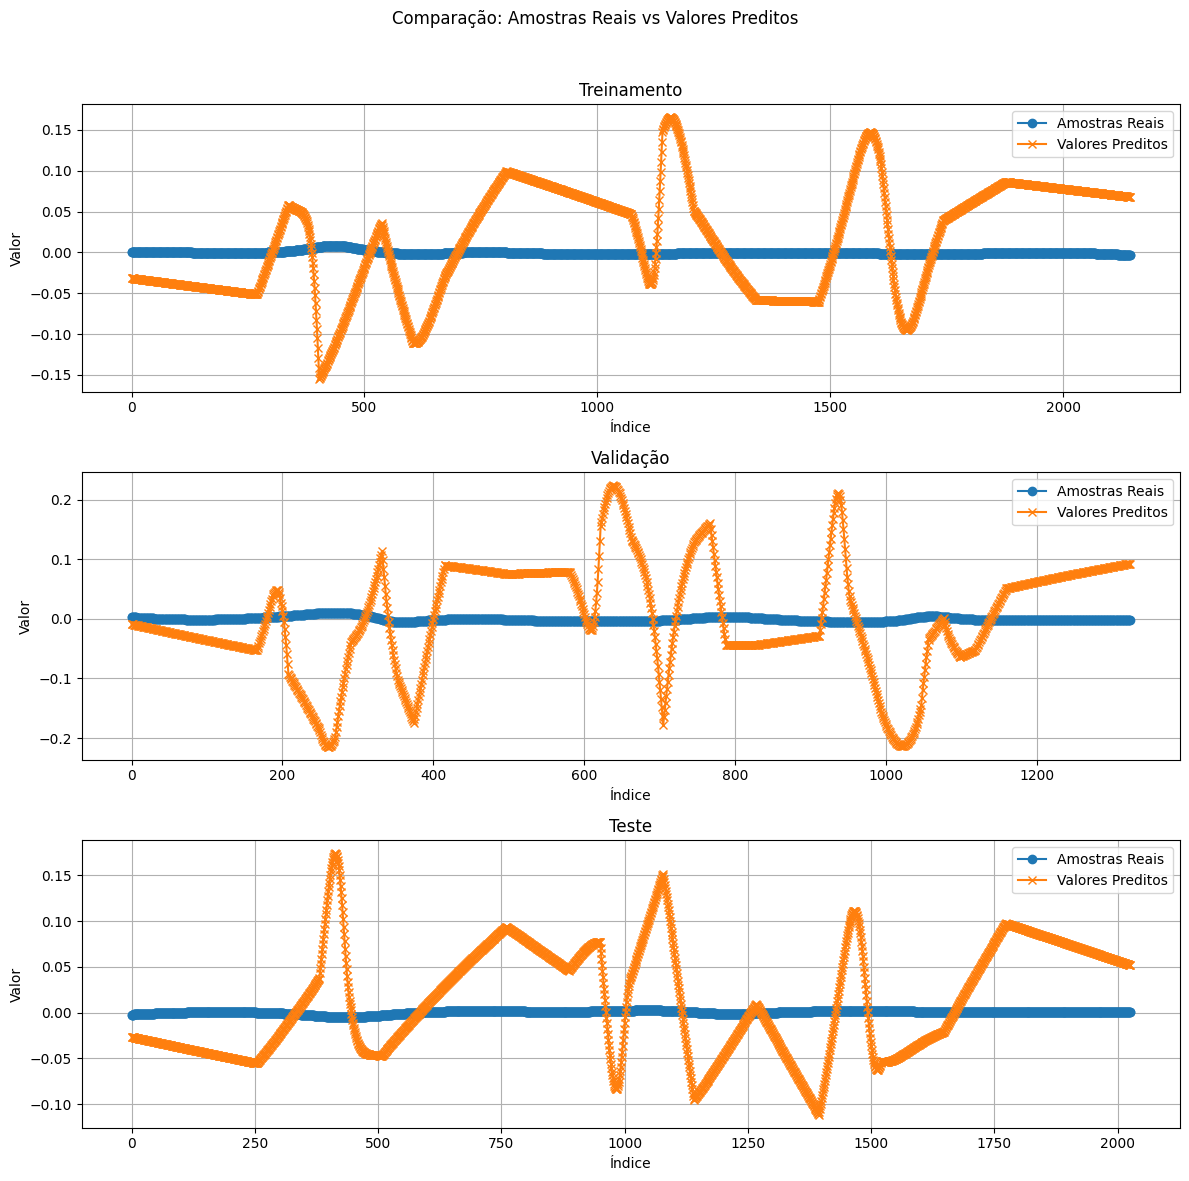

{'Training': {'R2': -1216.81494140625,
  'MSE': 0.004822564776986837,
  'RMSE': 0.06944468861609819,
  'MAPE': 191.1602783203125},
 'Validation': {'R2': -690.6174926757812,
  'MSE': 0.008932773023843765,
  'RMSE': 0.09451334838975797,
  'MAPE': 91.3977279663086},
 'Test': {'R2': -1390.951904296875,
  'MSE': 0.003785356180742383,
  'RMSE': 0.061525248319225685,
  'MAPE': 98.78952026367188}}

In [117]:
import os
import random

#os.environ['PYTHONHASHSEED'] = '37'
#os.environ['TF_DETERMINISTIC_OPS'] = '1'  # força operações determinísticas no TF (em CPU/GPU)
#random.seed(37)
#np.random.seed(37)
#tf.random.set_seed(37)

model_pinn = keras.Sequential([
    keras.layers.Input(shape=(len(PREDICTORS),)),
    keras.layers.Dense(5, activation='tanh'),
    keras.layers.Dense(1)
])


custom_train_model_with_es_physics(model_pinn,
                                       train_x = train_x_pinn, train_y = train_y_pinn,
                                       x_val = x_val, y_val = y_val,
                                       x_test = x_test, y_test = y_test,
                                       restrictions_data = Restrictions_data,
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       lambda1=0, lambda2=1.0,
                                       epochs = 10000, patience=5,
                                       min_delta=0, plot=True,
                                       learning_rate=0.01, use_early_stopping=True)

#Epoch 1: Loss=0.3381, MSE_d=0.3381, MSE_f=0.339, Val MSE=0.2454

In [ ]:
import optuna

# 1. Definir a Função Objetivo
def objective(trial):
    # Sugerir hiperparâmetros
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True) # Exemplo de LR logarítmico
    number_nn = trial.suggest_int('rnn_units_1', 10, 50, step=5) # Exemplo de unidades inteiras
    lambda_1 = trial.suggest_float('lambda1', 0, 1.0, step = 0.1) # Exemplo de lambda entre 0 e 1
    lambda2 = trial.suggest_float('lambda2', 0, 1.0, step = 0.1) 
    # Definir e compilar o modelo com os hiperparâmetros sugeridos

    model_pinn = keras.Sequential([
    keras.layers.Input(shape=(len(PREDICTORS),)),
    keras.layers.Dense(number_nn, activation='tanh'),
    keras.layers.Dense(1)
])

    # Treinar o modelo usando sua função personalizada
    # Retornamos apenas a val_loss, que queremos minimizar
    #metrics = custom_train_model_with_es(model, epochs=1000, patience=10, learning_rate=learning_rate, plot=False)


    metrics = custom_train_model_with_es_physics(model_pinn,
                                       train_x = train_x_pinn, train_y = train_y_pinn,
                                       x_val = x_val, y_val = y_val,
                                       x_test = x_test, y_test = y_test,
                                       restrictions_data = Restrictions_data,
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       lambda1=lambda_1, lambda2= lambda2,
                                       epochs = 10000, patience=4,
                                       min_delta=0, plot=False,
                                       learning_rate= learning_rate, use_early_stopping=True)

    # Retornar a métrica de validação que Optuna tentará minimizar
    return metrics['Validation']['MSE'] # ou 'RMSE', 'MAPE', dependendo do seu objetivo

# 2. Criar um Estudo
study = optuna.create_study(direction='minimize') # Queremos minimizar o MSE de validação

# 3. Executar a Otimização
study.optimize(objective, n_trials=100) # Tenta 50 combinações de hiperparâmetros

print(f"Melhor valor (MSE de validação): {study.best_value:.4f}")
print(f"Melhores hiperparâmetros: {study.best_params}")
#Melhores hiperparâmetros: {'learning_rate': 5.061078379468679e-05, 'rnn_units_1': 50, 'lambda1': 0.5, 'lambda2': 1.0}

Treinando com Ts=0.07, L=0.123, R=0.034, λ1=0.5, λ2=1
Epoch 1: Loss=0.8315, MSE_d=0.5549, MSE_f=0.5541, Val MSE=0.4457
Epoch 50: Loss=0.5927, MSE_d=0.3956, MSE_f=0.3949, Val MSE=0.3185
Epoch 100: Loss=0.4071, MSE_d=0.2718, MSE_f=0.2712, Val MSE=0.2201
Epoch 150: Loss=0.2715, MSE_d=0.1813, MSE_f=0.1808, Val MSE=0.1485
Epoch 200: Loss=0.1753, MSE_d=0.1171, MSE_f=0.1167, Val MSE=0.09773
Epoch 250: Loss=0.1094, MSE_d=0.07315, MSE_f=0.07283, Val MSE=0.06297
Epoch 300: Loss=0.06609, MSE_d=0.04423, MSE_f=0.04397, Val MSE=0.04014
Epoch 350: Loss=0.03892, MSE_d=0.02609, MSE_f=0.02588, Val MSE=0.02584
Epoch 400: Loss=0.02272, MSE_d=0.01526, MSE_f=0.01509, Val MSE=0.01732
Epoch 450: Loss=0.01355, MSE_d=0.009121, MSE_f=0.008988, Val MSE=0.01248
Epoch 500: Loss=0.008612, MSE_d=0.005813, MSE_f=0.005705, Val MSE=0.009863
Epoch 550: Loss=0.006077, MSE_d=0.004111, MSE_f=0.004022, Val MSE=0.008484
Epoch 600: Loss=0.004823, MSE_d=0.003266, MSE_f=0.00319, Val MSE=0.007759
Epoch 650: Loss=0.004209, MSE_d=0

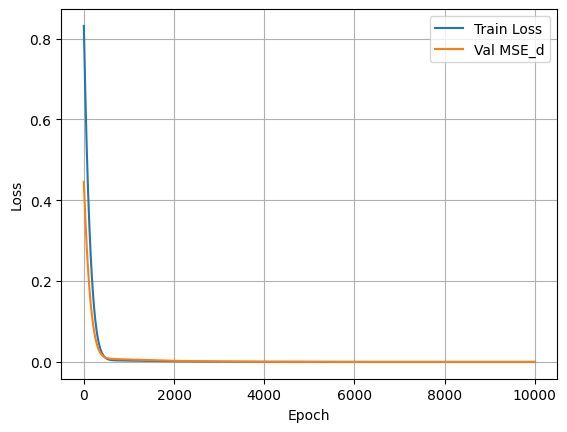

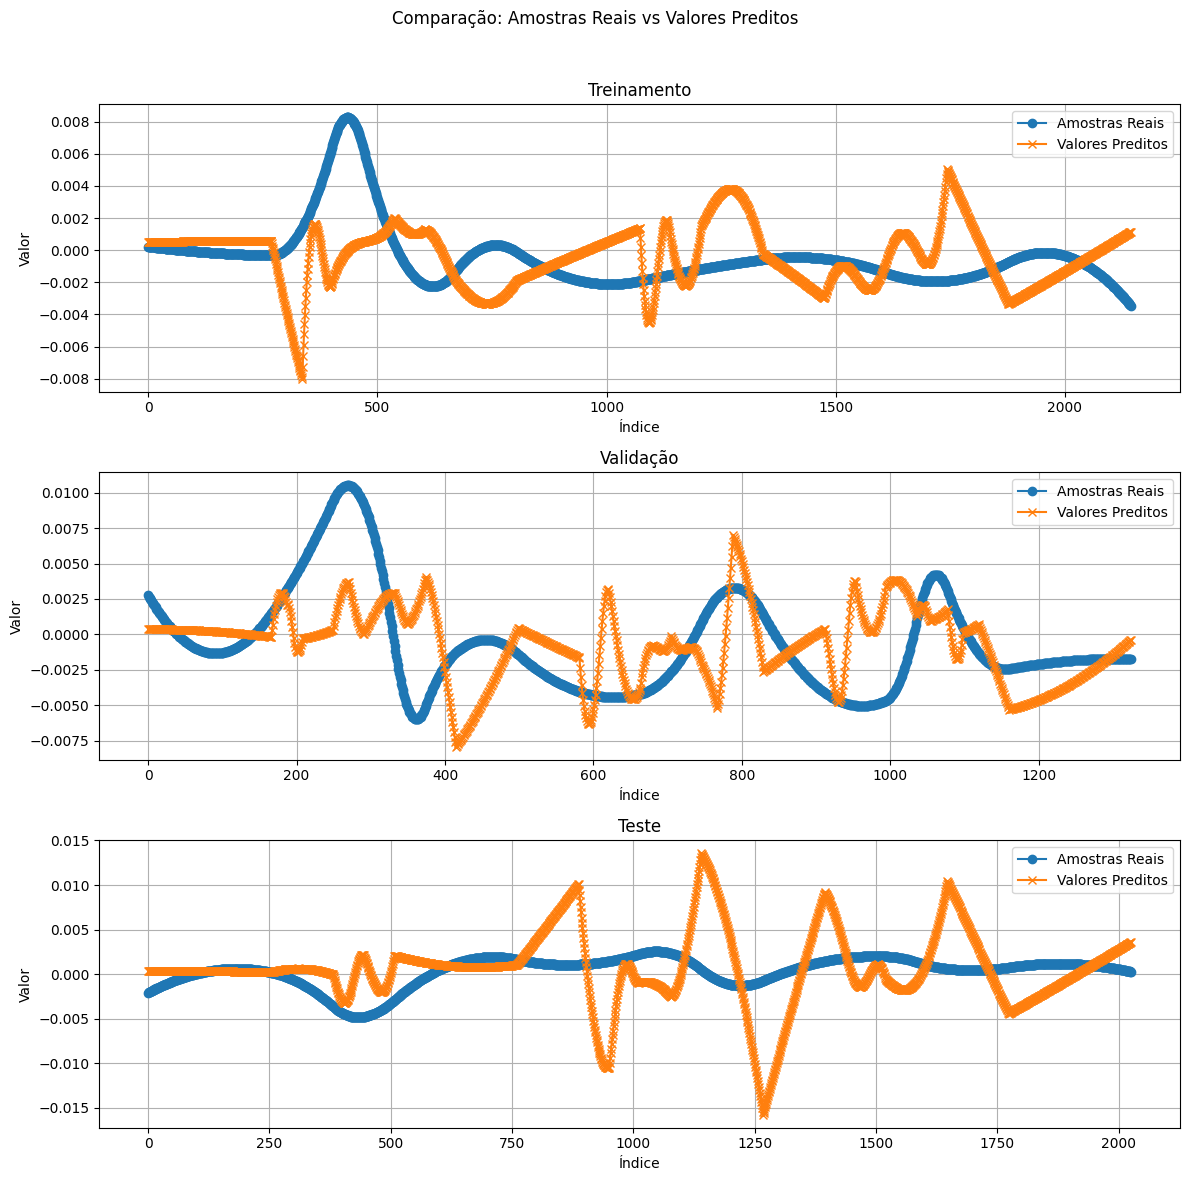

In [121]:
model_pinn_best = keras.Sequential([
    keras.layers.Input(shape=(len(PREDICTORS),)),
    keras.layers.Dense(50, activation='tanh'),
    keras.layers.Dense(1)
])

metrics = custom_train_model_with_es_physics(model_pinn_best,
                                       train_x = train_x_pinn, train_y = train_y_pinn,
                                       x_val = x_val, y_val = y_val,
                                       x_test = x_test, y_test = y_test,
                                       restrictions_data = Restrictions_data,
                                       Ts = 0.07, L = 0.123, R = 0.034,
                                       lambda1=0.5, lambda2= 1,
                                       epochs = 10000, patience=4,
                                       min_delta=0, plot=True,
                                       learning_rate= 5.061078379468679e-5, use_early_stopping=True)